# Cellpin Label Transfer Tutorial

Cellpin learns a robust embedding of scRNA-seq reference data, which makes it well-suited for **label transfer**: assigning cell-type annotations from an annotated reference to unlabelled spatial cells.

This notebook demonstrates:

| Section | Description |
|---------|-------------|
| **A — Standard** | Train cellpin and transfer cell-type labels from a scRNA reference to spatial data |

**Before running:** update the file paths in the *Load data* cell to point to your own `.h5ad` files.

## Setup

In [1]:
import cellpin
import torch
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

## Helper functions

`sample_square_from_center` — subsamples a spatial dataset to a square window centred on a random spot, expanding until `target_cells` cells are included. Used here to keep runtime manageable on large Xenium datasets.

In [2]:
def sample_square_from_center(
    adata,
    target_cells=50000,
    coord_key="spatial"
):
    coords = adata.obsm[coord_key]

    center = coords[np.random.randint(coords.shape[0])]
    x0, y0 = center

    d = 100

    while True:
        mask = (
            (coords[:,0] >= x0-d) &
            (coords[:,0] <= x0+d) &
            (coords[:,1] >= y0-d) &
            (coords[:,1] <= y0+d)
        )

        if mask.sum() >= target_cells:
            break

        d *= 1.2

    return adata[mask].copy()



## Load data

Both objects need raw integer counts — either in `.X` or in a named layer (set `LAYER` accordingly).

- `sc_adata`: single-cell reference atlas (full or highly-variable gene space)
- `sp_adata`: spatially-resolved dataset (panel genes only)

**Example data used here:**
- Single-cell: [Human Cell Lung Atlas (HCLA) core atlas](https://data.humancellatlas.org/hca-bio-networks/lung/atlases/lung-v1-0) — 4,000 HVGs
- Spatial: [10x Genomics Xenium Human Lung Preview Data](https://www.10xgenomics.com/datasets/xenium-human-lung-preview-data-1-standard)

In [ ]:
LAYER = "counts"      # layer with raw integer counts; set to None to use .X
CELL_TYPE_COL = "ann_level_3"  # column in sc_adata.obs with cell type labels

sc_adata = sc.read_h5ad("HCLA_core/4cb45d80-499a-48ae-a056-c71ac3552c94_hvg4000.h5ad") #adapt path to your own atlas
sc_data_counts = sc_adata.raw[sc_adata.obs_names, sc_adata.var_names] #object did not contain counts so we need to copy from anndata.raw
sc_adata.layers["counts"] = sc_data_counts.X
sc_adata.var_names = sc_adata.var["feature_name"] #update var names to match spatial data
sc.pp.subsample(sc_adata, n_obs=100_000, random_state=0) #subsample for speed
sp_adata = sc.read_h5ad("10X_Xenium/Lung_none_diseased/processed_sampleLung_10X_BC.h5ad") #adapt path to your own spatial data
sc.pp.filter_cells(sp_adata, min_genes=10)
sp_adata = sample_square_from_center(sp_adata, target_cells=50_000) #subsample for speed


/home/philipp/miniconda3/envs/cellpin_feat_atlas/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


## Data setup

`setup_data` aligns gene spaces and returns dataset objects used for training and inference.

In [4]:
sc_dataset, sp_dataset = cellpin.pp.setup_data(
    sc_adata, sp_adata, layer=LAYER,
     batch_key="dataset")

[cellpin.pp.setup] Setting up CellPin datasets


/home/philipp/miniconda3/envs/cellpin_feat_atlas/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


[cellpin.pp.setup] sc_adata :  100,000 cells  ×    4,000 genes
[cellpin.pp.setup] st_adata :   59,046 cells  ×      392 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 156 spatial gene(s) not found in sc_adata — will be dropped:
  ['ACE', 'ACE2', 'ACTR3', 'ADAM17', 'ADGRE5', 'AIF1', 'AK1', 'ALDH1A3', 'ALOX5', 'ANAPC16'] ...
[cellpin.pp.setup] Panel    : 236 genes overlap (60.2% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 4,000 genes total in sc space (3,764 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 100,000 cells, 4,000 genes total, 236 panel genes
[cellpin.pp.setup] st_dataset: 59,046 cells, 236 panel genes


/home/philipp/miniconda3/envs/cellpin_feat_atlas/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


---
# A) Standard cellpin — `model.fit()`

Two-stage training:
1. **Stage 1 — pretrain:** full-gene VAE (ELBO on all reference genes)
2. **Stage 2 — distillation:** panel encoder aligned to the full encoder via MSE + SNN + reconstruction from panel embedding

### A.1 — Train

In [5]:
t0 = time()
model_A = cellpin.CellPin(sc_dataset)
model_A.fit(
    sc_dataset,
    pretrain_epochs=50,
    train_epochs=60,
    save_checkpoints=False,
    batch_size=512,
)
time_A = time() - t0
print(f"Training time: {time_A / 60:.2f} minutes")

Epoch 59: 100%|██████████| 157/157 [00:08<00:00, 18.85it/s, v_num=13, val_loss=730.0, val_reconst_loss=615.0, val_kl_loss=61.20, val_kl_l_loss=2.660, val_distill_loss=0.0602, val_snn_loss=1.460, val_inv_loss=0.184, val_snn_temperature=0.0649, val_pearson_loss=0.670, train_loss=728.0, train_reconst_loss=612.0, train_kl_loss=60.90, train_kl_l_loss=2.600, train_distill_loss=0.0712, train_snn_loss=1.760, train_inv_loss=0.220, train_snn_temperature=0.0649, train_pearson_loss=0.656]
Training time: 14.83 minutes


### A.2 — Loss curves

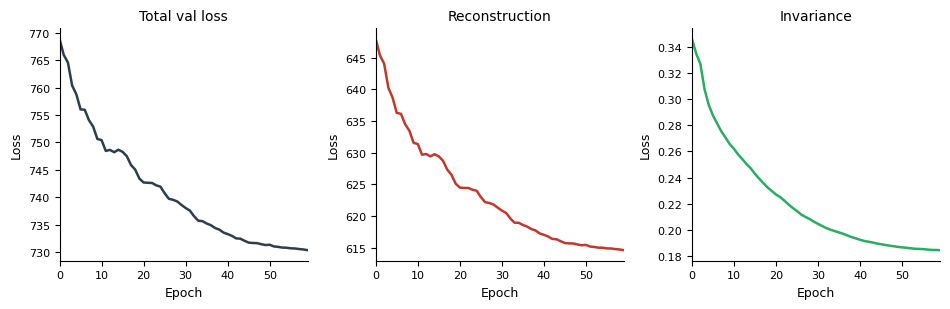

In [6]:
model_A.pl.losses(smooth=5)

### A.3 — Label transfer

Pass `confidence_threshold=` to `label_transfer()` to assign a low-confidence label (e.g. `"unknown"`) when the predicted class probability falls below a given threshold.

In [14]:
#Imputation not necessary for label transfer but we do it here just to plot values below:
dl_A = torch.utils.data.DataLoader(sp_dataset, batch_size=512, shuffle=False)
adata_imputed_A = model_A.impute(
    dl_A,
    obs_adata=sp_adata,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
    return_int=True)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 3764 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 3764 gene(s) absent from obs_adata layers with sentinel -2.0


In [23]:
acc_A, adata_annot_A = cellpin.tl.label_transfer(model_A, sc_adata, CELL_TYPE_COL, adata_imputed_A)



[label_transfer] 25 cell type classes
[label_transfer] Train: 80000 | Test: 20000
[label_transfer] Test accuracy: 0.9418
[label_transfer] Annotation complete. Annotations stored in sp_adata.obs['cellpin_annotation']


**A note on trusting the output:** a high test accuracy like the one above is a strong signal, but it's measured on held-out reference cells, not on the spatial data itself. Reference and query datasets can differ in ways that a single accuracy number won't catch — so we'd always recommend spot-checking the transferred labels against known marker genes and spatial context (as we do below) before treating them as ground truth in downstream analysis. Results can vary with dataset and tissue, and that quick sanity check is what turns a good accuracy score into a result you can actually rely on.

### A.4 — UMAP from cellpin embeddings

Cell embeddings in `obsm["X_cellpin"]` can be used directly to build a neighbourhood graph and compute a UMAP.

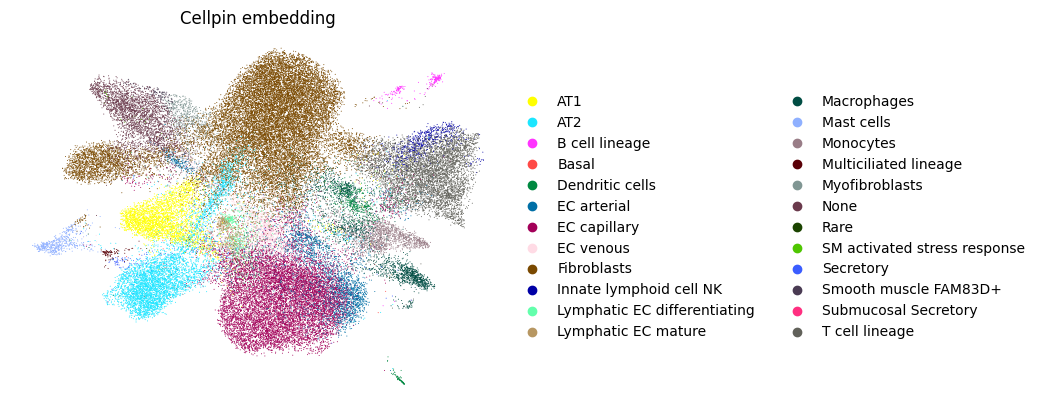

In [42]:
sc.pp.neighbors(adata_annot_A, use_rep="X_cellpin")
sc.tl.umap(adata_annot_A)
sc.pl.umap(adata_annot_A, color=["cellpin_annotation"],frameon=False, title="Cellpin embedding")


Spatial UMAP examples for a T cell lineage marker (`CD3E`), a Mast cell marker (`KIT`), and a B cell marker (`CD79A`), shown as both measured ground-truth and cellpin imputed expression.

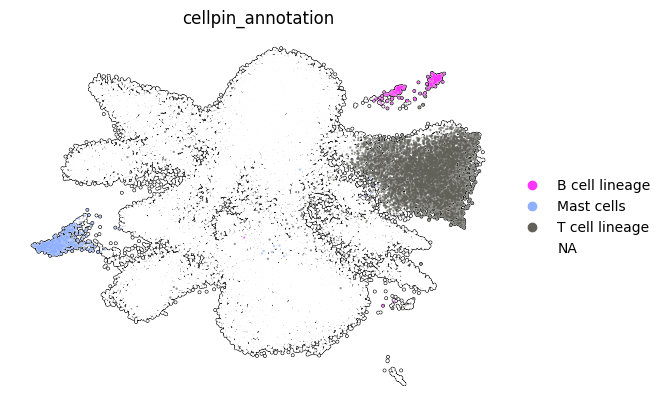

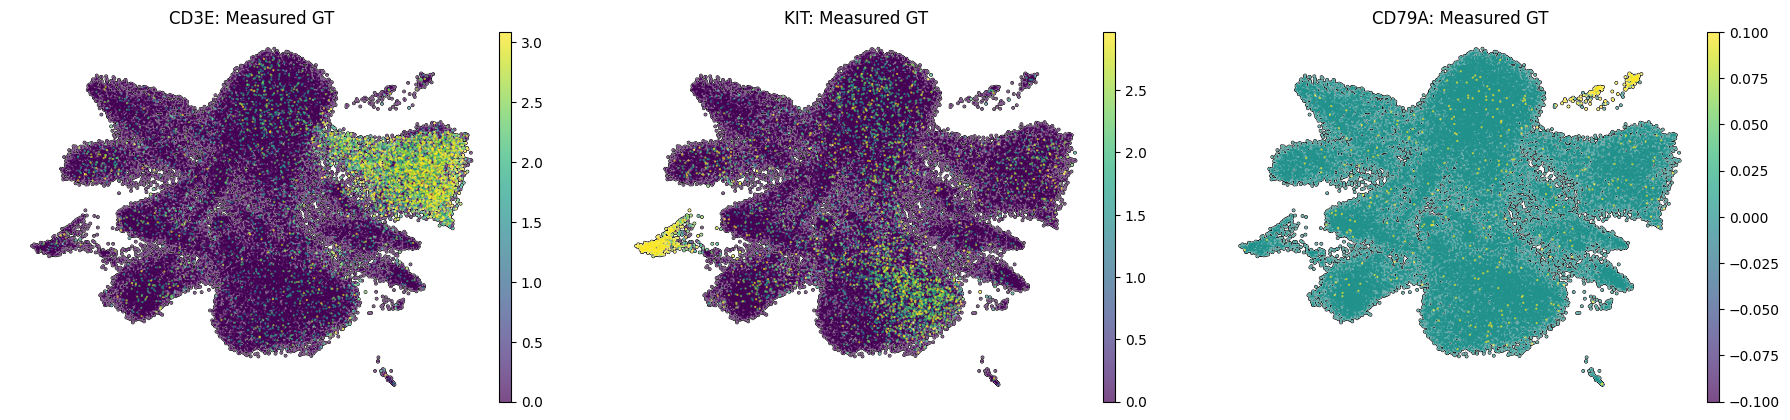

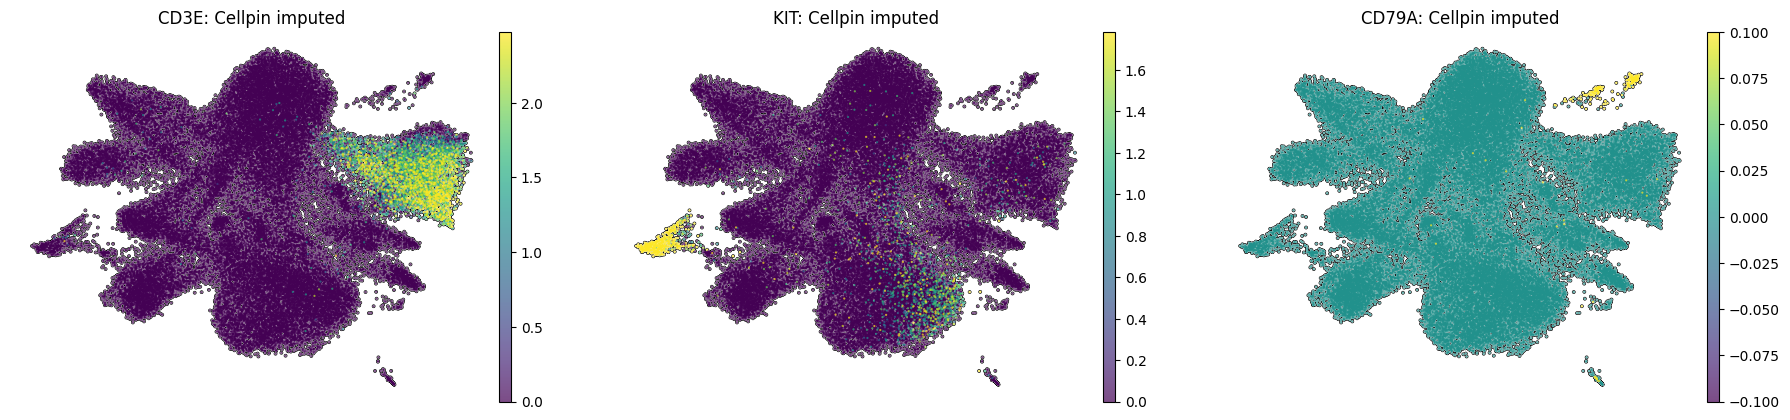

In [51]:
sc.pl.umap(adata_annot_A,color=["cellpin_annotation"],frameon=False,groups=["T cell lineage","Mast cells","B cell lineage"],size=10,add_outline=True,na_color="white")

sc.pl.umap(adata_annot_A,color=["CD3E","KIT","CD79A"],frameon=False,vmax="p99",layer="log1p_norm",add_outline=True,na_color="white",size=10,title=[f"{gene}: Measured GT" for gene in ["CD3E", "KIT", "CD79A"]])

sc.pl.umap(adata_annot_A,color=["CD3E","KIT","CD79A"],frameon=False,vmax="p99",layer="imputed_norm",add_outline=True,na_color="white",size=10, title=[f"{gene}: Cellpin imputed" for gene in ["CD3E", "KIT", "CD79A"]])